In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
import numpy as np
import pickle

from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def calc_fps(mols, fp_func):
    fps = [fp_func(m) for m in mols]
    return fps

def fit_decomp_kde(fps_train, pipe, kde):
    
    X_train_decomp = pipe.fit_transform(fps_train)
    kde.fit(X_train_decomp)
    
    return X_train_decomp

def plot_decomp_kde(X_decomp, kde, ax, cluster_labels=None):
        
    X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(100,100)

    # kernel density countour plot
    levels = np.linspace(0, Z.max(), 25)
    m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
    if cluster_labels == None:
        sns.scatterplot(x=X_decomp[:, 0], y=X_decomp[:, 1], s=2, ax=ax)
    else:
        sns.scatterplot(x=X_decomp[:, 0], y=X_decomp[:, 1], s=2, hue=cluster_labels, palette="viridis", legend="full", ax=ax)
        
    ax.grid(True)
    
    return X_decomp

In [2]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2).GetFingerprint
#fpgen = rdFingerprintGenerator.GetAtomPairGenerator().GetFingerprint

kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])
#pipe = Pipeline([('decomp', Isomap(n_components=2, n_neighbors=200)), ('scaler', MinMaxScaler((-1,1)))])

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros_minimal.smi", "r").readlines()]
mols_train = [Chem.MolFromSmiles(s) for s in smis_train]
fps_train = calc_fps(mols_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)

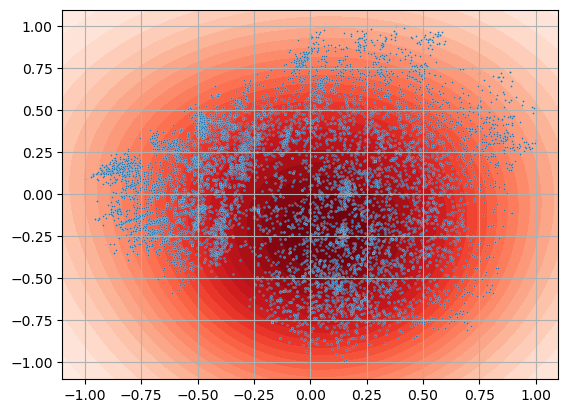

In [3]:
fig, ax = plt.subplots()
plot_decomp_kde(X_train_decomp, kde, ax)
plt.show()

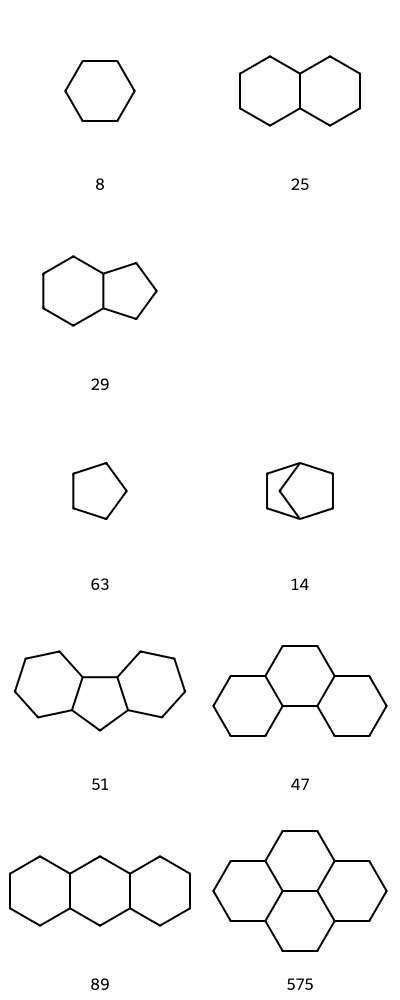

In [4]:
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd
from rdkit.Chem import Draw

def cluster_by_murckoscaffold(mols, makeGeneric=True, makeCyclicSkeleton=True, makeBajorath=True):
    """ Bemis and Murkco define 'atomic frameworks' as rings and linkers with sidechains removed
        'graph frameworks' (makeGeneric) are atomic frameworks with all atoms set to carbon and all bonds single
        'cyclic skeletons' (makeCyclicSkeletons) remove substituents, leave only rings and linkers
        'bajorath' (makeBajorath) also removes substituents, without replacing with a placeholder
    """
    
    PATT=Chem.MolFromSmarts("[$([D1]=[*])]")
    REPL=Chem.MolFromSmarts("[*]")
    
    # Inchis are the best way to detect duplicate mols
    unique_inchis = {}
    for idx, m in enumerate(mols):
        Chem.RemoveStereochemistry(m)
        scaf = MurckoScaffold.GetScaffoldForMol(m)
        if makeBajorath:
            scaf = AllChem.DeleteSubstructs(scaf, PATT)
        if makeCyclicSkeleton:
            scaf = AllChem.ReplaceSubstructs(scaf,PATT,REPL,replaceAll=True)[0]                                         
        if makeGeneric:
            scaf = MurckoScaffold.MakeScaffoldGeneric(scaf)
            if makeCyclicSkeleton:
                scaf = MurckoScaffold.GetScaffoldForMol(scaf)
            
        inchi = Chem.MolToInchi(scaf)
        if inchi not in unique_inchis.keys():
            unique_inchis[inchi] = [idx]
        else:
            unique_inchis[inchi].append(idx)
    
    # clusters are numbered by the inchi key index
    cluster_labels = np.full(len(mols), -1)
    for count, (inchi, idxs) in enumerate(unique_inchis.items()):
        cluster_labels[idxs] = count
        
    return cluster_labels, list(unique_inchis.keys())

cluster_labels, inchis = cluster_by_murckoscaffold(mols_train)
# Most common generic scaffolds
most_common = {}
for i in pd.Series(cluster_labels).value_counts().head(10).index:
    most_common[i] = Chem.MolFromInchi(inchis[i])
    
Draw.MolsToGridImage(most_common.values(), legends=[str(i) for i in list(most_common.keys())], molsPerRow=2)

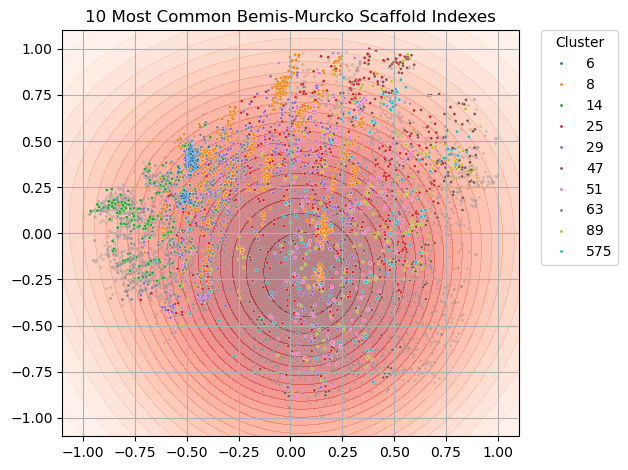

In [5]:
common_labels = np.array([i if i in most_common.keys() else 0 for i in cluster_labels])

fig, ax = plt.subplots()
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds, alpha=0.5)

plot_mask = np.array([x != 0 for x in common_labels])
X_plot = X_train_decomp[plot_mask,:]
X_else = X_train_decomp[~plot_mask,:]

sns.scatterplot(x=X_else[:, 0], y=X_else[:, 1], s=5, c="gray", alpha=0.3)
sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], s=5, hue=common_labels[plot_mask], palette="tab10", legend="full", ax=ax)

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
ax.grid(True)
ax.set_title("10 Most Common Bemis-Murcko Scaffold Indexes")
plt.tight_layout()
plt.show()

8897


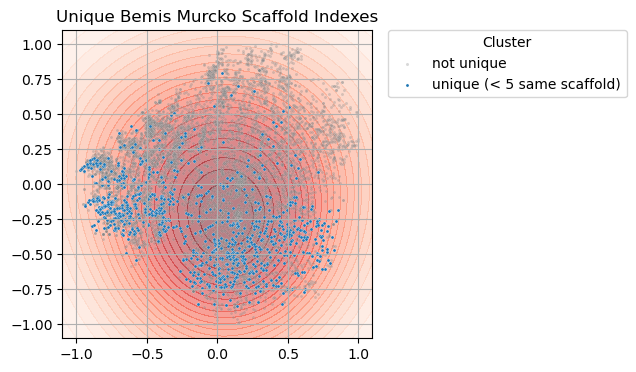

In [57]:
# "unique" frameworks (molecules not associated with any other molecule by BM framework)
least_common = {}
counts = pd.Series(cluster_labels).value_counts()
for i in counts[counts < 3].index:
    least_common[i] = Chem.MolFromInchi(inchis[i])
    
unique_labels = np.array([1 if i in least_common.keys() else 0 for i in cluster_labels])
    
fig, ax = plt.subplots(figsize=(4,4))
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds, alpha=0.5)

plot_mask = np.array([x != 0 for x in unique_labels])
print(len(plot_mask))
X_plot = X_train_decomp[plot_mask,:]
X_else = X_train_decomp[~plot_mask,:]

sns.scatterplot(x=X_else[:, 0], y=X_else[:, 1], s=5, c="gray", alpha=0.3, label="not unique")
sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], s=5, ax=ax, label="unique (< 5 same scaffold)")

plt.legend(
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
ax.grid(True)
ax.set_title("Unique Bemis Murcko Scaffold Indexes")
plt.show()

Examples:


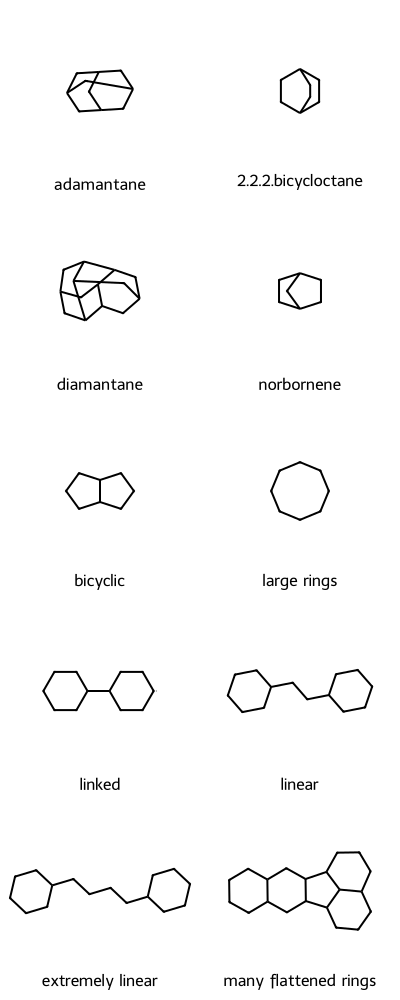

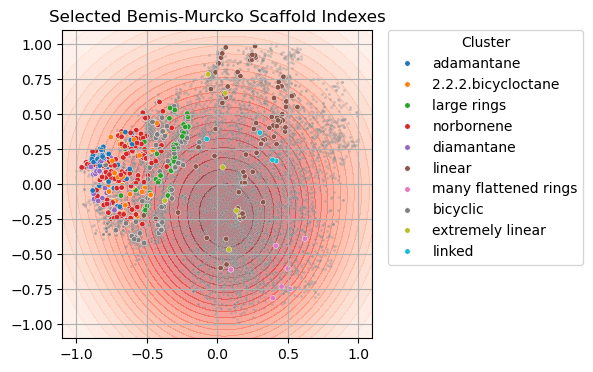

In [58]:
selected_structures = {
    "adamantane" : 3,
    "2.2.2.bicycloctane" : 5,
    "diamantane" : 19,
    "norbornene" : 14,
    "bicyclic" : 215,
    "large rings" : 11,
    "linked": 503,
    "linear": 36,
    "extremely linear": 239,
    "many flattened rings" : 182,
}

selected_labels = np.array([i if i in selected_structures.values() else 0 for i in cluster_labels])
examples = []
for i in selected_structures.values():
    #examples.append(mols_train[np.where(selected_labels==i)[0][0]])
    examples.append(Chem.MolFromInchi(inchis[i]))
img = Draw.MolsToGridImage(examples, legends=[f"{key}" for key, val in selected_structures.items()], molsPerRow=2)
print("Examples:")
display(img)

fig, ax = plt.subplots(figsize=(4, 4))
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds, alpha=0.5)

plot_mask = np.array([x != 0 for x in selected_labels])
X_plot = X_train_decomp[plot_mask,:]
X_else = X_train_decomp[~plot_mask,:]

sns.scatterplot(x=X_else[:, 0], y=X_else[:, 1], s=5, c="gray", alpha=0.3)
plot = sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], s=15, hue=selected_labels[plot_mask], palette="tab10", legend="full", ax=ax)

handles, labels = plot.get_legend_handles_labels()
smap = {str(v): k for k, v in selected_structures.items()}
new_labels = [smap[label] for label in labels]
plot.legend(
    handles=handles,
    labels=new_labels,
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
ax.grid(True)
ax.set_title("Selected Bemis-Murcko Scaffold Indexes")
plt.show()

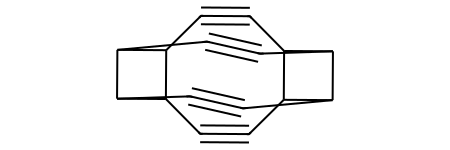

In [60]:
mols_train[37]

In [61]:
cluster_labels[37]

22

Examples:


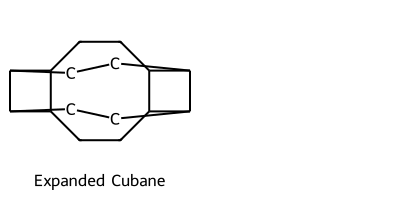

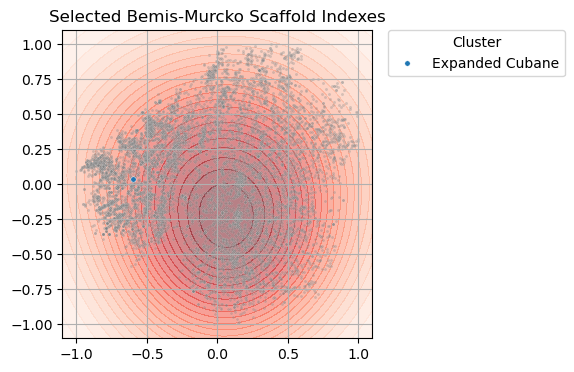

In [63]:
selected_structures = {
    "Expanded Cubane" : 22,
}

selected_labels = np.array([i if i in selected_structures.values() else 0 for i in cluster_labels])
examples = []
for i in selected_structures.values():
    #examples.append(mols_train[np.where(selected_labels==i)[0][0]])
    examples.append(Chem.MolFromInchi(inchis[i]))
img = Draw.MolsToGridImage(examples, legends=[f"{key}" for key, val in selected_structures.items()], molsPerRow=2)
print("Examples:")
display(img)

fig, ax = plt.subplots(figsize=(4, 4))
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds, alpha=0.5)

plot_mask = np.array([x != 0 for x in selected_labels])
X_plot = X_train_decomp[plot_mask,:]
X_else = X_train_decomp[~plot_mask,:]

sns.scatterplot(x=X_else[:, 0], y=X_else[:, 1], s=5, c="gray", alpha=0.3)
plot = sns.scatterplot(x=X_plot[:, 0], y=X_plot[:, 1], s=15, hue=selected_labels[plot_mask], palette="tab10", legend="full", ax=ax)

handles, labels = plot.get_legend_handles_labels()
smap = {str(v): k for k, v in selected_structures.items()}
new_labels = [smap[label] for label in labels]
plot.legend(
    handles=handles,
    labels=new_labels,
    title='Cluster',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
ax.grid(True)
ax.set_title("Selected Bemis-Murcko Scaffold Indexes")
plt.show()